# Transformer on PLAsTiCC: using augmented lightcurves, raw datapoints

This notebook uses the `dlip_plasticc` package on top of `avocado`.

### Notebook parameters

In [12]:
# Notebook parameters

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# Training
TRAIN_DATASET_NAME = 'plasticc_augment_daniil'
CLASSIFIER_NAME = 'my_transformer'
SEQ_LEN = 350
NUM_EPOCHS = 60
BATCH_SIZE = 64
LR = 1e-4
NUM_FOLDS = 5
RANDOM_STATE = 42
VAL_FOLD = 0
WEIGHT_DECAY = 1e-2
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 4
MIN_LR = 1e-6
EARLY_STOPPING_PATIENCE = 12

# Transformer architecture
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 4
DIM_FEEDFORWARD = 512
DROPOUT = 0.3

# Prediction
TEST_DATASET_NAME = 'plasticc_test'
TOTAL_CHUNKS = 500

CHUNKS = range(100)

# Output location for per-chunk and combined predictions.
OUT_DIR = '/scratch/s4339150/plasticc/predictions/transformer_predictions'

# Confusion matrix display options
CONFUSION_NORMALIZE = 'true'  # one of: None, 'true', 'pred', 'all'
FIGSIZE_HISTORY = (8, 5)
FIGSIZE_CONFUSION = (10, 8)

### Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.features import PlasticcSequenceFeaturizer
from dlip_plasticc.models import TransformerClassifier
from dlip_plasticc.pipelines.predict import predict_partial_from_dataset
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

### Paths

These are set by the `avocado_settings.json` file.

In [3]:
# Load config and push paths into avocado
cfg = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(cfg)

print('Using avocado paths:')
print('  data_directory       =', avocado.settings['data_directory'])
print('  features_directory   =', avocado.settings['features_directory'])
print('  predictions_directory=', avocado.settings['predictions_directory'])
print('  classifier_directory =', avocado.settings['classifier_directory'])

Using avocado paths:
  data_directory       = /scratch/s4339150/plasticc/data
  features_directory   = /scratch/s4339150/plasticc/features
  predictions_directory= /scratch/s4339150/plasticc/predictions
  classifier_directory = /scratch/s4339150/plasticc/classifiers


### Determine class weights

In [ ]:
# get class counts from training metadata
metadata = avocado.load('plasticc_augment_daniil', metadata_only=True).metadata
class_counts = metadata['class'].value_counts()

# dampened inverse frequency 
DAMPING = 0.5 # raise to power < 1 to soften the effect
inv_freq = 1.0 / class_counts
inv_freq = inv_freq ** DAMPING
inv_freq = inv_freq / inv_freq.mean()  # normalise so mean = 1

class_weights = inv_freq.to_dict()
print(class_weights)

{90: 0.3428638567577157, 16: 0.46790670714945, 42: 0.47502686939593874, 65: 0.49859290648245874, 15: 0.6557511927179571, 88: 0.7670256212687797, 62: 0.7830713376017605, 92: 0.8882289777209923, 95: 1.0911402443623275, 6: 1.1750549023222183, 67: 1.1985998858360851, 52: 1.2454436323165041, 64: 1.9042423353494153, 53: 2.507051530718397}


## 1. Train the transformer

This uses online sequence featurisation from raw observations in the training dataset.

In [24]:
featurizer = PlasticcSequenceFeaturizer(seq_len=SEQ_LEN)

classifier = TransformerClassifier(
    name=CLASSIFIER_NAME,
    featurizer=featurizer,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    class_weights=class_weights,
)

print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
train_dataset = avocado.load(TRAIN_DATASET_NAME)

print('Extracting sequence raw features...')
train_dataset.extract_raw_features(featurizer)

print(f"Training classifier '{CLASSIFIER_NAME}'...")
classifier.train(
    train_dataset,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

print(f"Best validation loss: {classifier.best_val_loss:.5f}")


Loading training dataset 'plasticc_augment_daniil'...
Extracting sequence raw features...


Object: 100%|██████████| 95914/95914 [01:07<00:00, 1430.44it/s]


Training classifier 'my_transformer'...


Epochs:   2%|▏         | 1/60 [00:24<24:29, 24.91s/it]

Epoch 1 train_loss: 1.79367 val_loss: 1.65689 val_acc: 0.48430 lr: 1.000000e-04


...

Epoch 44 train_loss: 0.70901 val_loss: 1.00084 val_acc: 0.70832 lr: 1.250000e-05


Epochs:  75%|███████▌  | 45/60 [29:07<10:08, 40.59s/it]

Epoch 45 train_loss: 0.70182 val_loss: 0.98309 val_acc: 0.70858 lr: 1.250000e-05


Epochs:  75%|███████▌  | 45/60 [29:49<09:56, 39.76s/it]

Epoch 46 train_loss: 0.69770 val_loss: 0.97324 val_acc: 0.71035 lr: 1.250000e-05
Early stopping at epoch 46. Best val_loss: 0.95359
Best validation loss: 0.95359
Best validation loss: 0.95359


In [25]:
# Save the trained classifier
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)


Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_transformer.pkl


## 2. Plot training history

In [26]:
history = classifier.history.copy()
history.tail()

,epoch,train_loss,val_loss,val_acc,lr
41,42,0.714806,0.978472,0.708891,0.000025
42,43,0.711050,0.998620,0.706495,0.000025
43,44,0.709014,1.000836,0.708318,0.000013
44,45,0.701823,0.983086,0.708579,0.000013
45,46,0.697697,0.973236,0.710349,0.000013


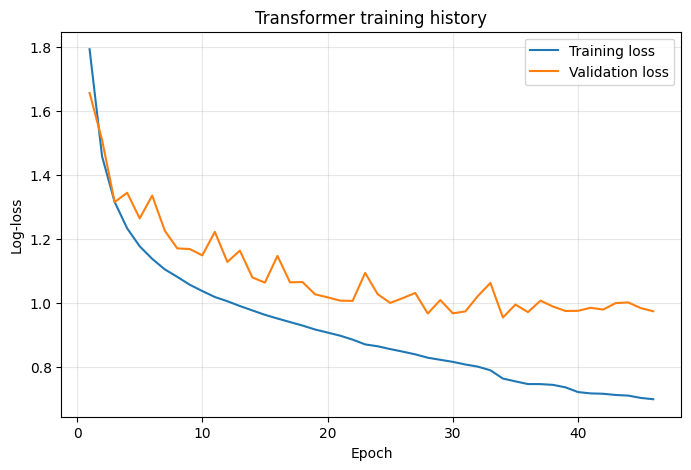

In [27]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['train_loss'], label='Training loss')
ax.plot(history['epoch'], history['val_loss'], label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Log-loss')
ax.set_title('Transformer training history')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 3. Predict on test chunks

In [4]:
# Load the trained classifier for prediction and scoring if needed 
classifier = avocado.load_classifier(CLASSIFIER_NAME)

featurizer = PlasticcSequenceFeaturizer(seq_len=SEQ_LEN)

In [7]:
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

combined_predictions, processed_chunks = predict_partial_from_dataset(
    classifier=classifier,
    featurizer=featurizer,
    dataset_name=TEST_DATASET_NAME,
    total_chunks=TOTAL_CHUNKS,
    chunks=CHUNKS,
    out_dir=OUT_DIR,
    metadata_only=False,
    show_progress=True,
)

print('Processed chunks:', processed_chunks)
print('Combined prediction shape:', combined_predictions.shape)
combined_predictions.head()


Object: 100%|██████████| 6985/6985 [00:05<00:00, 1336.01it/s]
/home6/s4339150/miniconda/envs/project/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
Chunks: 100%|██████████| 100/100 [12:05<00:00,  7.26s/it]


Processed chunks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Combined prediction shape: (698578, 14)


,6,15,16,42,52,53,62,64,65,67,88,90,92,95
object_id,,,,,,,,,,,,,,
plasticc_000000013,0.000006,9.177534e-07,5.270576e-07,0.570988,0.295610,1.489992e-11,0.020111,3.081686e-10,0.000004,0.000233,3.358930e-06,0.072963,3.967217e-11,0.040080
plasticc_000000014,0.000239,1.579855e-03,1.770622e-05,0.198750,0.228376,3.403933e-09,0.036450,2.530075e-06,0.000463,0.019132,2.120741e-03,0.490611,1.196501e-08,0.022259
plasticc_000000017,0.000033,1.119187e-04,1.820744e-05,0.421093,0.131448,1.241522e-10,0.111416,1.253988e-05,0.009369,0.018436,3.426218e-05,0.306153,1.773449e-09,0.001875
plasticc_000000023,0.000014,6.355654e-06,1.113449e-05,0.177241,0.154098,1.547386e-10,0.165335,2.948054e-07,0.000178,0.096052,1.216628e-05,0.385972,1.353201e-09,0.021080
plasticc_000000034,0.000006,1.649694e-05,7.604429e-08,0.031611,0.077276,1.399792e-15,0.012453,6.928033e-08,0.000023,0.003882,2.975587e-08,0.874552,9.346205e-12,0.000180


In [14]:
combined_predictions.to_pickle(Path(OUT_DIR) / "transformer_full_predictions.pkl")

In [15]:
combined_predictions = pd.read_pickle(Path(OUT_DIR) / "transformer_full_predictions.pkl")

## 4. Score predictions with avocado flat-weighted logloss and other metrics

This scores only on the overlapping labeled objects available in the metadata.

In [17]:
from __future__ import annotations

from typing import Tuple, Union

import numpy as np
import pandas as pd
import avocado

from avocado.utils import AvocadoException


MetadataSource = Union[str, pd.DataFrame]


def load_metadata(metadata_source: MetadataSource) -> pd.DataFrame:
    """Load metadata from a dataset name or return it directly."""
    if isinstance(metadata_source, pd.DataFrame):
        metadata = metadata_source.copy()
    else:
        dataset = avocado.load(metadata_source, metadata_only=True)
        metadata = dataset.metadata.copy()

    return metadata


def normalize_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize prediction rows so each row sums to 1."""
    df = df.copy()
    row_sums = df.sum(axis=1)

    if (row_sums <= 0).any():
        bad = row_sums[row_sums <= 0]
        raise AvocadoException(
            f"Cannot normalize predictions: found {len(bad)} rows with non-positive sums."
        )

    df = df.div(row_sums, axis=0)

    if df.isnull().values.any():
        raise AvocadoException("NaNs encountered while normalizing prediction rows.")

    return df


def _coerce_prediction_columns(
    pred_df: pd.DataFrame,
    true_classes: pd.Series,
) -> pd.DataFrame:
    """Try to coerce prediction columns to the dtype of the true classes."""
    pred_df = pred_df.copy()

    try:
        pred_df.columns = pred_df.columns.astype(true_classes.dtype)
    except Exception:
        pass

    return pred_df


def align_truth_and_predictions(
    metadata_source: MetadataSource,
    pred_df: pd.DataFrame,
    known_classes_only: bool = True,
    normalize: bool = False,
) -> Tuple[pd.Series, pd.DataFrame]:
    """Align ground-truth classes and predictions on common object IDs.

    Parameters
    ----------
    metadata_source
        Either a dataset name understood by `avocado.load(..., metadata_only=True)`
        or a metadata DataFrame indexed by object_id.
    pred_df
        Prediction DataFrame indexed by object_id and columns keyed by class label.
    known_classes_only
        If True, keep only rows whose true class is present in `pred_df.columns`.
    normalize
        If True, row-normalize the predictions before returning.

    Returns
    -------
    true_classes : pandas.Series
    pred_aligned : pandas.DataFrame
    """
    metadata = load_metadata(metadata_source)

    if "class" not in metadata.columns:
        raise AvocadoException("Metadata does not contain a 'class' column.")

    if pred_df.index.name != "object_id":
        pred_df = pred_df.copy()
        pred_df.index.name = "object_id"

    common_idx = metadata.index.intersection(pred_df.index)
    if len(common_idx) == 0:
        raise AvocadoException("No overlap between metadata and predictions.")

    true_classes = metadata.loc[common_idx, "class"].copy()
    pred_aligned = pred_df.loc[common_idx].copy()

    pred_aligned = _coerce_prediction_columns(pred_aligned, true_classes)

    if known_classes_only:
        known_mask = true_classes.isin(set(pred_aligned.columns))
        true_classes = true_classes.loc[known_mask]
        pred_aligned = pred_aligned.loc[known_mask]

    pred_aligned = pred_aligned.reindex(true_classes.index)

    if pred_aligned.isnull().values.any():
        raise AvocadoException("Predictions contain NaNs after alignment.")

    if normalize:
        pred_aligned = normalize_rows(pred_aligned)

    return true_classes, pred_aligned


def score_flat(
    metadata_source: MetadataSource,
    pred_df: pd.DataFrame,
    class_weights: dict | None = None,
    known_classes_only: bool = True,
    normalize: bool = True,
) -> Tuple[float, int]:
    """Compute avocado flat-weighted logloss.

    By default, uses the PLAsTiCC flat weights.
    """
    if class_weights is None:
        class_weights = avocado.plasticc.plasticc_flat_weights

    true_classes, pred_aligned = align_truth_and_predictions(
        metadata_source=metadata_source,
        pred_df=pred_df,
        known_classes_only=known_classes_only,
        normalize=normalize,
    )

    score = avocado.weighted_multi_logloss(
        true_classes,
        pred_aligned,
        class_weights=class_weights,
    )

    return score, len(true_classes)

def score_redshift(
    metadata_source: MetadataSource,
    pred_df: pd.DataFrame,
    class_weights: dict | None = None,
    known_classes_only: bool = True,
    normalize: bool = True,
    redshift_key: str = "redshift",
) -> Tuple[float, int]:
    """Compute avocado redshift-weighted logloss."""
    if class_weights is None:
        class_weights = avocado.plasticc.plasticc_flat_weights

    metadata = load_metadata(metadata_source)

    # Build a temporary dataset-like object for evaluate_weights_redshift
    class _MetadataDataset:
        def __init__(self, metadata):
            self.metadata = metadata

    true_classes, pred_aligned = align_truth_and_predictions(
        metadata_source=metadata,
        pred_df=pred_df,
        known_classes_only=known_classes_only,
        normalize=normalize,
    )

    dataset = _MetadataDataset(metadata.loc[true_classes.index])

    object_weights = avocado.evaluate_weights_redshift(
        dataset, redshift_key=redshift_key
    )

    score = avocado.weighted_multi_logloss(
        true_classes,
        pred_aligned,
        object_weights=object_weights,
        class_weights=class_weights,
    )

    return score, len(true_classes)


def score_kaggle(
    metadata_source: MetadataSource,
    pred_df: pd.DataFrame,
    class_weights: dict | None = None,
    known_classes_only: bool = True,
    normalize: bool = True,
) -> Tuple[float, int]:
    """Compute avocado Kaggle-weighted logloss (no object weights, kaggle class weights)."""
    if class_weights is None:
        class_weights = avocado.plasticc.plasticc_kaggle_weights

    true_classes, pred_aligned = align_truth_and_predictions(
        metadata_source=metadata_source,
        pred_df=pred_df,
        known_classes_only=known_classes_only,
        normalize=normalize,
    )

    score = avocado.weighted_multi_logloss(
        true_classes,
        pred_aligned,
        class_weights=class_weights,
    )

    return score, len(true_classes)

In [8]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, combined_predictions)
print(f'Flat-weighted logloss: {flat_score:.5f}')
print(f'Objects scored:        {n_scored:,}')

Flat-weighted logloss: 0.98954
Objects scored:        695,910


In [18]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, combined_predictions)
print(f"Flat-weighted logloss:     {flat_score:.5f}  (n={n_scored:,})")

redshift_score, n_scored = score_redshift(TEST_DATASET_NAME, combined_predictions)
print(f"Redshift-weighted logloss: {redshift_score:.5f}  (n={n_scored:,})")

kaggle_score, n_scored = score_kaggle(TEST_DATASET_NAME, combined_predictions)
print(f"Kaggle-weighted logloss:   {kaggle_score:.5f}  (n={n_scored:,})")

Flat-weighted logloss:     0.98954  (n=695,910)
Redshift-weighted logloss: 0.98301  (n=695,910)
Kaggle-weighted logloss:   1.01833  (n=695,910)


## 5. Confusion matrix and classification report

In [9]:
# Labels for plots

plot_labels = {
    6: 'Single micro-lens - 6',
    15: 'TDE - 15',
    16: 'Eclipsing Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_short = {
    6: 'Single $\mu$-lens - 6',
    15: 'TDE - 15',
    16: 'Eclip. Binary - 16',
    42: 'SNII - 42',
    52: 'SNIax - 52',
    53: 'Mira - 53',
    62: 'SNIbc - 62',
    64: 'Kilonova - 64',
    65: 'M-dwarf - 65',
    67: 'SNIa-91bg - 67',
    88: 'AGN - 88',
    90: 'SNIa - 90',
    92: 'RR lyrae - 92',
    95: 'SLSN-I - 95',
    99: 'Unknown - 99',
}

plot_labels_extra_short = {
    6: 'Single $\mu$-lens',
    15: 'TDE',
    16: 'Eclip. Binary',
    42: 'SNII',
    52: 'SNIax',
    53: 'Mira',
    62: 'SNIbc',
    64: 'Kilonova',
    65: 'M-dwarf',
    67: 'SNIa-91bg',
    88: 'AGN',
    90: 'SNIa',
    92: 'RR lyrae',
    95: 'SLSN-I',
    99: 'Unknown',
}

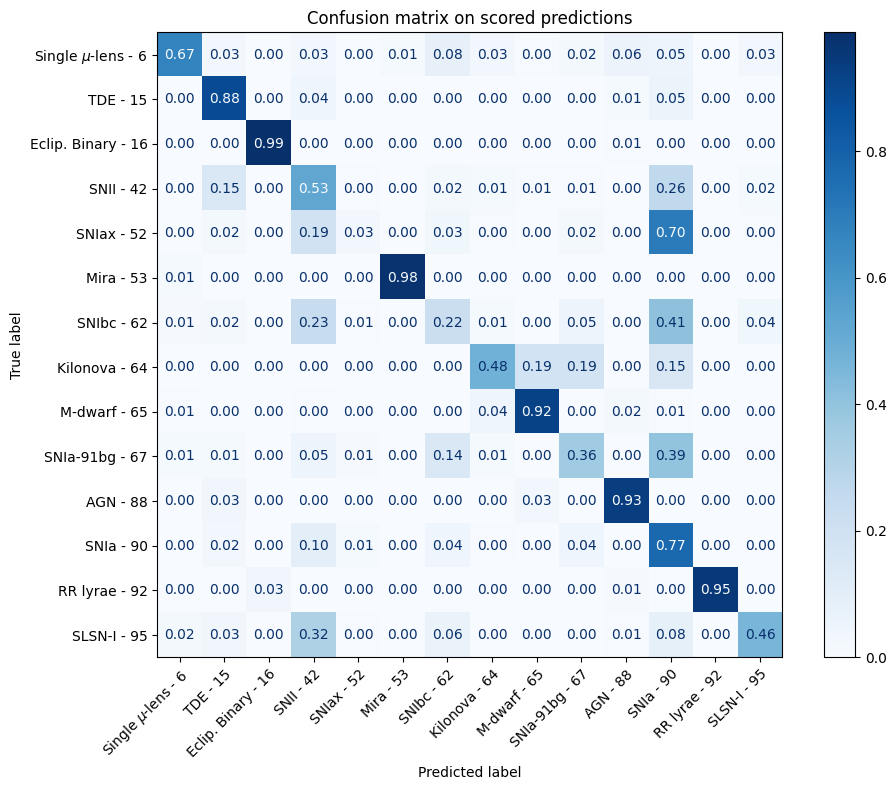

In [19]:
y_true, pred_aligned = align_truth_and_predictions(
    TEST_DATASET_NAME,
    combined_predictions,
    known_classes_only=True,
    normalize=True,
)

y_pred = pred_aligned.idxmax(axis=1)
labels = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

# map numeric class ids to readable labels
display_labels = [plot_labels_short.get(l, str(l)) for l in labels]

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels,  # readable labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=True,
    cmap=plt.cm.Blues,
    values_format=".2f",
)

ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation=45, 
    ha='right',  # anchors the label end under the tick
    rotation_mode='anchor'
)

ax.set_title("Confusion matrix on scored predictions")
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           6     0.0713    0.6695    0.1289       233
          15     0.0561    0.8837    0.1056      2648
          16     0.9350    0.9879    0.9608     18744
          42     0.6978    0.5257    0.5996    204756
          52     0.0654    0.0302    0.0413     12972
          53     0.8675    0.9752    0.9182       282
          62     0.2823    0.2217    0.2484     35479
          64     0.0023    0.4815    0.0046        27
          65     0.8867    0.9154    0.9008     18114
          67     0.1522    0.3607    0.2140      7999
          88     0.9158    0.9326    0.9241     19805
          90     0.7594    0.7720    0.7656    329642
          92     0.9976    0.9539    0.9753     38170
          95     0.3753    0.4619    0.4141      7039

    accuracy                         0.6744    695910
   macro avg     0.5046    0.6551    0.5144    695910
weighted avg     0.7158    0.6744    0.6891    695910

